<a href="https://colab.research.google.com/github/Mercedes1798/Python_Data_Analysis_Project/blob/main/Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION

To conclude the course, a small EDA (exploratory data analysis) project will be carried out - one that makes use of the same dataset used throughout the lessons and puts to work all the skills learned during the course.

## Goals
1. Investigate roles and skills in the data science industry.
2. Use Python to explore a real-life dataset on job postings.

To meet the goals above, answering the following questions is key.
1. What are the most in-demand skills for the top 3 most popular data roles?
2. How well do jobs and skills pay for Data Analysts?
3. What is are optimal skills to learn as Data Analysts? (High demand AND high paying)

A subset of the entire dataframe will often be used i.e. one that includes only postings in Germany.

---
# I. MOST IN-DEMAND SKILLS

Q/ What are the most in-demand skills for the top 3 most popular data roles?

In [ ]:
# Import dataset and basic clean up

import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

First we must narrow down our dataset to include only postings in Germany.

In [ ]:
df_DE = df[df["job_country"]=="Germany"]

Now we need to get the job skills out of the lists they're in and give them their own individual row i.e. we're gonna use .explode().

In [ ]:
df_explode = df_DE.explode("job_skills").copy()

Next, we must group skills and roles while also extracting the count of each skill with its respective role.

In [ ]:
df_skill_count = df_explode.groupby(["job_title_short", "job_skills"]).size()
df_skill_count.head(5)

job_title_short   job_skills
Business Analyst  airflow       12
                  alteryx        8
                  angular        2
                  asana          1
                  asp.net        1
dtype: int64

The result from the code above is a Series object, which isn't ideal. If left as a Series, job_title_short and job_skills would be indeces and the counts would go into an unnamed column interpreted as the Series's values. Using the .reset_index() method, we can simultaneously turn the Series into a df and rename the column where the skill counts are.

**Note:** .reset_index() works differently on a Series than it does on a df!

In [ ]:
df_skill_count = df_skill_count.reset_index(name='skill_count')
df_skill_count.head(5)

# Now none of our columns is an index and they're properly labelled

,job_title_short,job_skills,skill_count
0,Business Analyst,airflow,12
1,Business Analyst,alteryx,8
2,Business Analyst,angular,2
3,Business Analyst,asana,1
4,Business Analyst,asp.net,1


Next we must sort the df in terms of descending skill count values.

In [ ]:
df_skill_count = df_skill_count.sort_values(by="skill_count", ascending=False)
df_skill_count.head(10)

,job_title_short,job_skills,skill_count
679,Data Scientist,python,4157
500,Data Engineer,python,3524
530,Data Engineer,sql,3145
336,Data Analyst,sql,2947
312,Data Analyst,python,2309
707,Data Scientist,sql,2137
384,Data Engineer,azure,1961
683,Data Scientist,r,1795
383,Data Engineer,aws,1649
346,Data Analyst,tableau,1366


We must now narrow down the job titles to the 3 most important ones i.e. the ones that come up the most. It makes our lives easier that we already know these roles to be data analyst, data engineer, and data scientist. How would we go about extracting this information from our data though?

In [ ]:
# job_titles = df_skill_count["job_title_short"].unique()
# Returns an array!

job_titles = df_skill_count["job_title_short"].unique().tolist()
job_titles

['Data Scientist',
 'Data Engineer',
 'Data Analyst',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Senior Data Analyst',
 'Software Engineer',
 'Business Analyst',
 'Machine Learning Engineer',
 'Cloud Engineer']

In [ ]:
job_titles = sorted(job_titles[0:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

We've got all we need to start plotting.

In [ ]:
import seaborn as sns

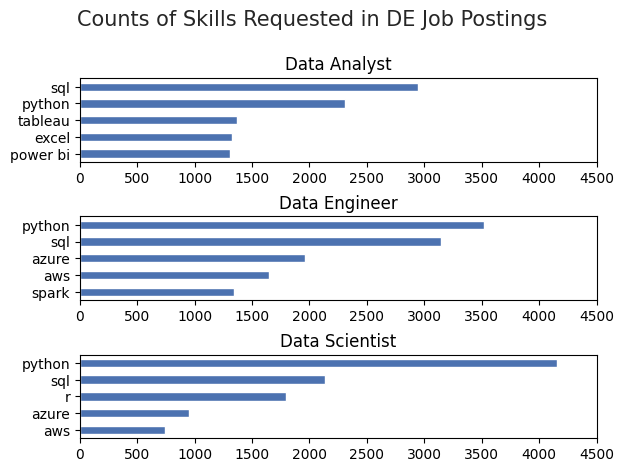

In [ ]:
fig, ax = plt.subplots(3,1)

sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
  df_plot = df_skill_count[df_skill_count["job_title_short"] == job_title].head(5)
  df_plot.plot(kind="barh", x="job_skills", y="skill_count", ax=ax[i], title=job_title)
  ax[i].set_title(job_title)
  ax[i].invert_yaxis()
  ax[i].set_ylabel('')
  ax[i].set_xlabel('')
  ax[i].get_legend().remove()
  ax[i].set_xlim(0, 4500) # make the scales the same

fig.suptitle('Counts of Skills Requested in DE Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()

The visualization above is already quite good, but we can make it better using Seaborn.

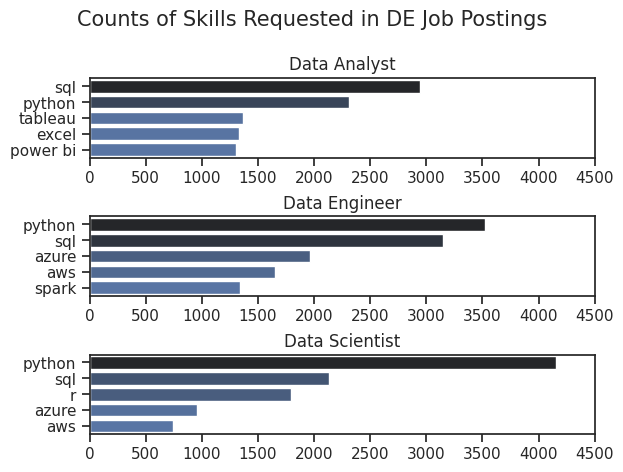

In [ ]:
fig, ax = plt.subplots(3,1)

sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
  df_plot = df_skill_count[df_skill_count["job_title_short"] == job_title].head(5)
  #df_plot.plot(kind="barh", x="job_skills", y="skill_count", ax=ax[i], title=job_title)
  sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
  ax[i].set_title(job_title)
  ax[i].set_ylabel('')
  ax[i].set_xlabel('')
  ax[i].get_legend().remove()
  ax[i].set_xlim(0, 4500) # make the scales the same

fig.suptitle('Counts of Skills Requested in DE Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()



## Demand percentages

We'll turn skill counts into something more insightful: percentage of jobs requesting each skill.

First off, we must find the total job count for each job title.

In [ ]:
df_job_title_count = df_DE["job_title_short"].value_counts().reset_index(name="jobs_total")

# Notice how we use again the .reset_index() method to turn the series into a df

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,7131
1,Data Scientist,6745
2,Data Engineer,6675
3,Senior Data Engineer,2041
4,Senior Data Scientist,1737
5,Senior Data Analyst,1216
6,Business Analyst,817
7,Software Engineer,741
8,Machine Learning Engineer,402
9,Cloud Engineer,189


Now we must calculate how often each skill appears under each job title in terms of a percentage i.e. divide `skill_count` by `jobs_total`.

Append `jobs_total` to `df_skill_count` and add a new column with the quotient (i.e. the percentage)  and multiply by 100 to remove the decimal.

In [ ]:
df_skill_prct = pd.merge(df_skill_count, df_job_title_count, on="job_title_short", how="left")

# Add a new column with the percentage
df_skill_prct["skill_percent"] = ((df_skill_prct["skill_count"] / df_skill_prct["jobs_total"]) * 100)

df_skill_prct

,job_title_short,job_skills,skill_count,jobs_total,skill_percent
0,Data Scientist,python,4157,6745,61.630838
1,Data Engineer,python,3524,6675,52.794007
2,Data Engineer,sql,3145,6675,47.116105
3,Data Analyst,sql,2947,7131,41.326602
4,Data Analyst,python,2309,7131,32.379750
...,...,...,...,...,...
1377,Data Analyst,fortran,1,7131,0.014023
1378,Data Analyst,centos,1,7131,0.014023
1379,Senior Data Analyst,assembly,1,1216,0.082237
1380,Business Analyst,selenium,1,817,0.122399


We've got everything we need to plot. We'll need to make some adjustments like rounding the percentage and removing the decimals, but we can mostly just reuse the code from before.

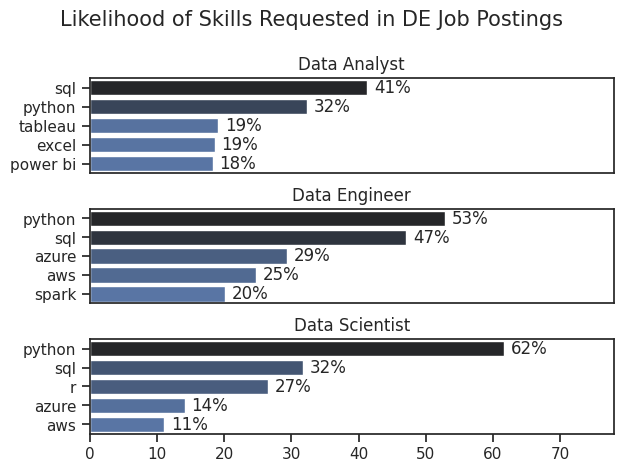

In [ ]:
fig, ax = plt.subplots(3, 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_skill_prct[df_skill_prct['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # remove the x-axis tick labels of all ax except the last for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in DE Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()

---
# II. SKILL VS. PAY

Q/ How do skills, including the most popular skills, relate to job pay?

The ultimate goal is to find out what the highest paying skills (median) and the most popular skills are (with their respective median pay) regarding the top 6 data roles.

First we'll investigate how salaries look like in general for the top 6 data roles.

In [ ]:
# Import dataset and basic clean up

import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Naturally, we must filter our data to include jobs in Germany only and given that NaN values for salary would wreck our analysis, we'll remove them.

In [ ]:
df_DE = df[df["job_country"] == "Germany"].dropna(subset=["salary_year_avg"])

Find out what the top 6 data roles are and filter the df_DE to include only these titles.

In [ ]:
job_titles = df_DE["job_title_short"].value_counts() # Already sorted in descensing order

job_titles = df_DE["job_title_short"].value_counts().index[0:6].to_list()

job_titles

['Data Analyst',
 'Data Scientist',
 'Data Engineer',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [ ]:
df_DE_top6 = df_DE["job_title_short"].isin(job_titles) # Returns "array" of Bool values

df_DE_top6 = df_DE[df_DE["job_title_short"].isin(job_titles)]

df_DE_top6.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1363,Data Scientist,Master Data Management Plants (f/m/div.),"Karlsruhe, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-08-18 13:27:39,False,False,Germany,year,56700.0,NaN,Bosch Group,[spark],{'libraries': ['spark']}
7772,Data Engineer,Research Engineer Bio-MEMS Sensors (f/m/div.),"Renningen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-04-25 13:14:38,False,False,Germany,year,199675.0,NaN,Bosch Group,[spark],{'libraries': ['spark']}
10610,Senior Data Engineer,"Senior Data Engineer - Infrastructure, TIDAL","Berlin, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-22 13:26:27,True,False,Germany,year,147500.0,NaN,Block,"[go, redshift, snowflake, aws, gdpr, hadoop, s...","{'cloud': ['redshift', 'snowflake', 'aws'], 'l..."
20066,Data Analyst,Data Analyst Logistik (w/m/d),"Salzgitter, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-12-20 13:17:42,True,False,Germany,year,75067.5,NaN,PowerCo,"[r, python, java, c#, sql]","{'programming': ['r', 'python', 'java', 'c#', ..."
20526,Machine Learning Engineer,Senior ML Engineer (m/f/d),"Berlin, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-01-22 13:18:29,False,False,Germany,year,185500.0,NaN,Flink,[python],{'programming': ['python']}


We're interested in knowing the top 6 roles' median salary, sorting them accordingly, and extracting the titles.

In [ ]:
top6_pay = df_DE_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index

top6_pay

Index(['Senior Data Scientist', 'Data Engineer', 'Senior Data Engineer',
       'Data Scientist', 'Data Analyst', 'Machine Learning Engineer'],
      dtype='object', name='job_title_short')

We've got all the data we need for plotting some box plots. We can easily borrow the code from the advanced matplotlib and seaborn sections.

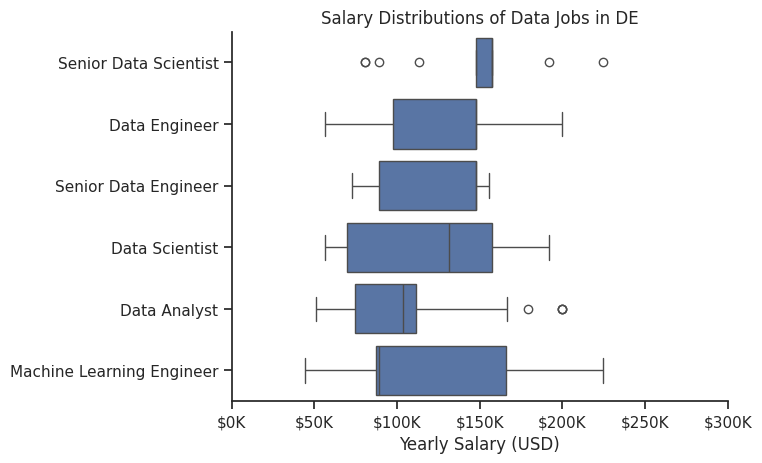

In [ ]:
sns.boxplot(data=df_DE_top6, x='salary_year_avg', y='job_title_short', order=top6_pay)
sns.set_theme(style='ticks')
sns.despine()

# Borrowed formatting to make everything look nicer
plt.title('Salary Distributions of Data Jobs in DE')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

NOTE: I suspect the sample size is so low because the vast majority of German listings do not include salary information. We're working with a very small dataset here, prone to skewance due to outliers.

## Highest paid and most popular skills

Now we're gonna get more specific and narrow down our data to data analyst positions in Germany only. We'll find out what the highest paid and most popular skills for data analysts are, along with their associated salaries.

In [ ]:
df_DA_DE = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "Germany")].copy()

# Remove NaN values from the salary column
df_DA_DE = df_DA_DE.dropna(subset=["salary_year_avg"])

# Explode the skills column so every skill gets its own row
df_DA_DE = df_DA_DE.explode("job_skills")

df_DA_DE.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
20066,Data Analyst,Data Analyst Logistik (w/m/d),"Salzgitter, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-12-20 13:17:42,True,False,Germany,year,75067.5,NaN,PowerCo,r,"{'programming': ['r', 'python', 'java', 'c#', ..."
20066,Data Analyst,Data Analyst Logistik (w/m/d),"Salzgitter, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-12-20 13:17:42,True,False,Germany,year,75067.5,NaN,PowerCo,python,"{'programming': ['r', 'python', 'java', 'c#', ..."
20066,Data Analyst,Data Analyst Logistik (w/m/d),"Salzgitter, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-12-20 13:17:42,True,False,Germany,year,75067.5,NaN,PowerCo,java,"{'programming': ['r', 'python', 'java', 'c#', ..."
20066,Data Analyst,Data Analyst Logistik (w/m/d),"Salzgitter, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-12-20 13:17:42,True,False,Germany,year,75067.5,NaN,PowerCo,c#,"{'programming': ['r', 'python', 'java', 'c#', ..."
20066,Data Analyst,Data Analyst Logistik (w/m/d),"Salzgitter, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-12-20 13:17:42,True,False,Germany,year,75067.5,NaN,PowerCo,sql,"{'programming': ['r', 'python', 'java', 'c#', ..."


Find the associated salary of each skill, sort in descending order according to the median, and filter for the first 5 skills. That's how you find the highest paid ones.

In [ ]:
df_DA_top_pay = df_DA_DE.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(5)

df_DA_top_pay

,count,median
job_skills,,
github,3,199675.0
bigquery,1,166419.5
nosql,1,166419.5
kafka,1,166419.5
redshift,1,166419.5


To find the most popular once, the code is very similar to the one above, you just have to sort by count first and then the median.

In [ ]:
df_DA_skills = df_DA_DE.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(5).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
python,18,111175.0
excel,7,105650.0
sql,24,101500.0
tableau,13,100500.0
r,7,75067.5


Similar to what we've done before, we'll plot our data in a single figure with two axes. We can borrow the code from the lessons once more.

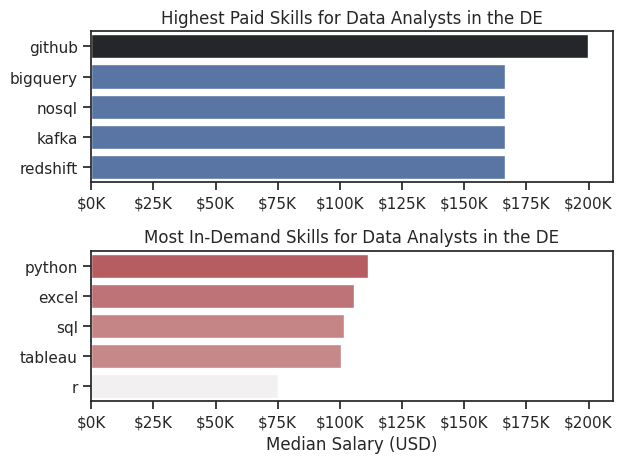

In [ ]:
fig, ax = plt.subplots(2, 1)

# Highest Paid Skills
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# Using plt: df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Highest Paid Skills for Data Analysts in DE')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Most In-Demand Skills
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='light:r')
ax[1].legend().remove()
# Using plt: df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Most In-Demand Skills for Data Analysts in DE')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()

---
# III. OPTIMAL SKILLS

Q/ For Data Analysts in Germany, what are the skills that are both high-demand AND high-pay?

This section is a continuum of section II, but instead of bar charts we'll graph a scatter plot (again, similar to what we did in the lessons i.e. borrow-able code).

In [ ]:
# Import dataset and basic clean up

import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [ ]:
# Generate a subset for Germany and data analysts only
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

# Drop all NaNs in the salary column
df_DA_DE = df_DA_DE.dropna(subset=['salary_year_avg'])

Since we need to have each individual skill with its associated job title, we're gonna create a new df that contains them.

In [ ]:
df_DA_DE_exploded = df_DA_DE.explode("job_skills")

df_DA_DE_exploded[['salary_year_avg', 'job_skills']].head(5) # inspection

,salary_year_avg,job_skills
20066,75067.5,r
20066,75067.5,python
20066,75067.5,java
20066,75067.5,c#
20066,75067.5,sql


We will group the data by job skills (rows) and calculate the count and median salary for each skill, sorting the results in descending order by count + rename the columns.

In [ ]:
df_DA_skills = df_DA_DE_exploded.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values("count", ascending=False)

df_DA_skills = df_DA_skills.rename(columns={"count":"skill_count", "median":"median_salary"})

df_DA_skills

,skill_count,median_salary
job_skills,,
sql,24,101500.00
python,18,111175.00
tableau,13,100500.00
excel,7,105650.00
r,7,75067.50
spark,7,111175.00
looker,5,53014.00
pandas,4,108412.50
go,4,52014.00


We will calculate the individual percentage of skill count over the total number of Data Analyst jobs and save it to a new column.

In [ ]:
DA_job_count = len(df_DA_DE)

df_DA_skills["skill_prct"] = (df_DA_skills["skill_count"] / DA_job_count) * 100

df_DA_skills

,skill_count,median_salary,skill_prct
job_skills,,,
sql,24,101500.00,50.000000
python,18,111175.00,37.500000
tableau,13,100500.00,27.083333
excel,7,105650.00,14.583333
r,7,75067.50,14.583333
spark,7,111175.00,14.583333
looker,5,53014.00,10.416667
pandas,4,108412.50,8.333333
go,4,52014.00,8.333333



Filter out any jobs that don't have any skills associated with them.

In [ ]:
df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] > 0]

df_DA_skills

,skill_count,median_salary,skill_prct
job_skills,,,
sql,24,101500.00,50.000000
python,18,111175.00,37.500000
tableau,13,100500.00,27.083333
excel,7,105650.00,14.583333
r,7,75067.50,14.583333
spark,7,111175.00,14.583333
looker,5,53014.00,10.416667
pandas,4,108412.50,8.333333
go,4,52014.00,8.333333


Finally, before plotting, exclude skills that come up in less than 5% of job postings.

In [ ]:
df_DA_high_demand = df_DA_skills[df_DA_skills["skill_prct"] > 5]

df_DA_high_demand

,skill_count,median_salary,skill_prct
job_skills,,,
sql,24,101500.0,50.000000
python,18,111175.0,37.500000
tableau,13,100500.0,27.083333
excel,7,105650.0,14.583333
r,7,75067.5,14.583333
spark,7,111175.0,14.583333
looker,5,53014.0,10.416667
pandas,4,108412.5,8.333333
go,4,52014.0,8.333333


Time to plot. Let's create a scatter plot of skill against demand percentage. REUSE CODE!

In [ ]:
!pip install adjustText

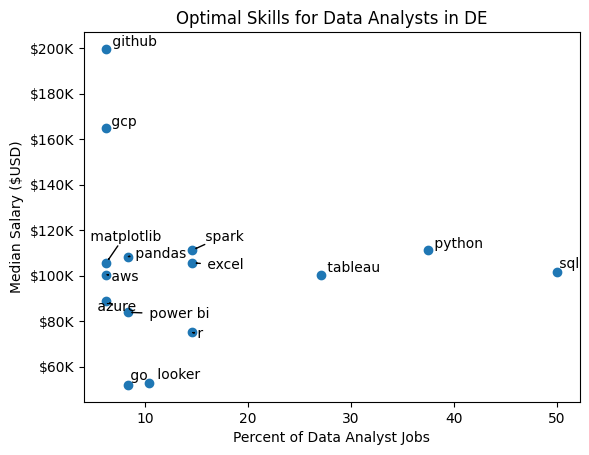

In [ ]:
from adjustText import adjust_text

plt.scatter(df_DA_high_demand['skill_prct'], df_DA_high_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
plt.title('Optimal Skills for Data Analysts in DE')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_high_demand.index):
    texts.append(plt.text(df_DA_high_demand['skill_prct'].iloc[i], df_DA_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

plt.show()

## Color-coding by skill category

To enhance the scatter plot above, we'll color-code each skill according to its category (programming, cloud, analysis, etc).

First, let's inspect the column we'll be using: `job_type_skills`.


In [ ]:
df["job_type_skills"].head(5)

,job_type_skills
0,None
1,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,"{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [ ]:
type(df["job_type_skills"].iloc[1])

str

The data in this column is stored as dictionary-like strings where the keys are the categories (the course calls them technologies) and the values are lists containing the skills themselves. First, we will remove duplicates and Nones.

In [ ]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

We want to combine the dictionaries into a single dictionary with no duplicates whatsoever. The keys will still be the skill type and the values will still be skills, but for the entire data set.

In [ ]:
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

The code above still leaves us with plenty of duplicate values for each key. A simple way to remove them is to turn the values' lists into sets, and then back to lists.

In [ ]:
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [ ]:
technology_dict

{'analyst_tools': ['sas',
  'microstrategy',
  'alteryx',
  'sheets',
  'word',
  'msaccess',
  'excel',
  'power bi',
  'sap',
  'ssis',
  'spreadsheet',
  'ssrs',
  'nuix',
  'looker',
  'ms access',
  'cognos',
  'outlook',
  'dax',
  'visio',
  'powerbi',
  'tableau',
  'esquisse',
  'sharepoint',
  'datarobot',
  'splunk',
  'qlik',
  'powerpoint',
  'spss'],
 'programming': ['apl',
  'sas',
  'c++',
  'php',
  'css',
  'kotlin',
  'solidity',
  'lisp',
  'shell',
  'assembly',
  'pascal',
  'erlang',
  'julia',
  'mongo',
  'java',
  'python',
  'dart',
  'delphi',
  'r',
  'c',
  'perl',
  'ruby',
  't-sql',
  'bash',
  'sql',
  'visualbasic',
  'objective-c',
  'vba',
  'haskell',
  'crystal',
  'clojure',
  'fortran',
  'html',
  'visual basic',
  'golang',
  'no-sql',
  'nosql',
  'javascript',
  'vb.net',
  'elixir',
  'lua',
  'typescript',
  'ocaml',
  'matlab',
  'c#',
  'mongodb',
  'groovy',
  'sass',
  'go',
  'f#',
  'cobol',
  'rust',
  'scala',
  'powershell',
  'sw

Now we'll convert the dictionary into a df and we'll explode the keys i.e. each skill will have its own row along with its associated category.

In [ ]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sas
0,analyst_tools,microstrategy
0,analyst_tools,alteryx
0,analyst_tools,sheets
0,analyst_tools,word
...,...,...
9,sync,rocketchat
9,sync,microsoft teams
9,sync,symphony
9,sync,twilio


We'll merge `df_DA_skills` with our newly created `df_technology`.

In [ ]:
df_plot = df_DA_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skill_prct,technology,skills
0,24,101500.0,50.000000,programming,sql
1,18,111175.0,37.500000,programming,python
2,13,100500.0,27.083333,analyst_tools,tableau
3,7,105650.0,14.583333,analyst_tools,excel
4,7,75067.5,14.583333,programming,r
5,7,111175.0,14.583333,libraries,spark
6,5,53014.0,10.416667,analyst_tools,looker
7,4,108412.5,8.333333,libraries,pandas
8,4,52014.0,8.333333,programming,go
9,4,83937.5,8.333333,analyst_tools,power bi


A little explanation on how the code above works:
* left_on=`job_skills`: Tells Pandas to look at the column named 'job_skills' in the first df (df_DA_high_demand) to find values to match (e.g., 'python', 'excel', 'aws').

* right_on=`skills`: Tells Pandas to look at the column named 'skills' in the second df (df_technology) to find corresponding values.
* The merge reset the index too (?)

Recall there's a 5% threshold regarding the `skill_prct`, meaning that the skills included in the plot appear in 5% (or higher) of the postings.



Time to plot.

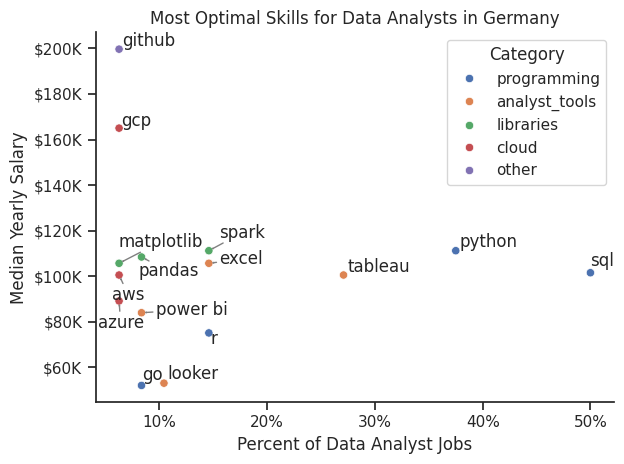

In [ ]:
sns.scatterplot(
    data=df_plot,
    x='skill_prct',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_high_demand.index):
    texts.append(plt.text(df_DA_high_demand['skill_prct'].iloc[i], df_DA_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Germany')
plt.legend(title='Category')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show()